[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SwissChardLeaf/icrn/blob/main/docs/tutorials/pre_computed_state.ipynb)
[![View on GitHub](https://img.shields.io/badge/source-GitHub-blue?logo=github)](https://github.com/SwissChardLeaf/icrn/blob/main/docs/tutorials/pre_computed_state.ipynb)

Pre-computed State
==================

Sometimes a species should follow a trajectory that is fixed ahead of time rather than determined by the network dynamics. Examples include an experimentally measured input, an externally controlled signal (light, temperature, a syringe pump), or a catalyst whose concentration is dictated by some other process.

icrn's solvers accept a `pre_computed_state` argument for exactly this. The supplied species is **injected into the state at every solver step**: the rest of the network sees its value and reacts to it, but the species itself follows the supplied values instead of its own dynamics. In other words, the pre-computed state is *catalytic*.

If you are running this notebook on Colab, install icrn first.

In [ ]:
!uv pip install icrn

# A driven production reaction

Consider a catalytic species `C` that drives the production of `A`:

$$ C \longrightarrow A + C $$

Because `C` appears on both sides, it is not consumed; it simply catalyzes production of `A` at a rate proportional to its concentration.

In [1]:
from icrn import MassActionReaction, many_species

A, C = many_species("A, C")

rxns = [MassActionReaction(C, A + C, 1.0)]

# Building the pre-computed trajectory

The solver takes `max_steps`. The `pre_computed_state` is a dictionary mapping a species to the values it should take. The leading axes of the tensors must have length `max_steps+1` for every solver step and the intial state.

$$ \texttt{max\_step}= \left\lceil \frac{t_\text{final}}{\texttt{dt}} \right\rceil, $$

In this example, `C` follows a rectangular pulse: it is off, switches on between $t=3$ and $t=7$, then switches off again.

In [ ]:
import math

import jax.numpy as jnp

dt = 0.01
times = jnp.linspace(0.0, 10.0, 1001)

conc_vals = {
    A: jnp.array(0.0),
    C: jnp.array(0.0),
}  # C's value is overridden by the trajectory

# one value of C per solver step, including the initial step
num_solver_steps = math.ceil(float(times[-1]) / dt) + 1
step_times = dt * jnp.arange(num_solver_steps)

C_trajectory = jnp.where((step_times >= 3.0) & (step_times <= 7.0), 1.0, 0.0)
pre_computed_state = {C: C_trajectory}

print("solver steps:", num_solver_steps)
print("C_trajectory shape:", C_trajectory.shape)

solver steps: 1001
C_trajectory shape: (1001,)


# Solving with the pre-computed state

Pass the dictionary to `solve_well_mixed` via the `pre_computed_state` keyword. The initial value supplied for `C` in `conc_vals` is overridden at every step by the trajectory.

In [3]:
from icrn import solve_well_mixed

result = solve_well_mixed(
    rxns,
    conc_vals,
    {},
    times,
    dt,
    reaction_solver="Euler",
    pre_computed_state=pre_computed_state,
)

`C` follows the forced pulse exactly, and `A` accumulates while the pulse is on, plateauing once `C` returns to zero. The final value of `A` equals the area under the pulse (a width-4 pulse of height 1, so `A` reaches 4).

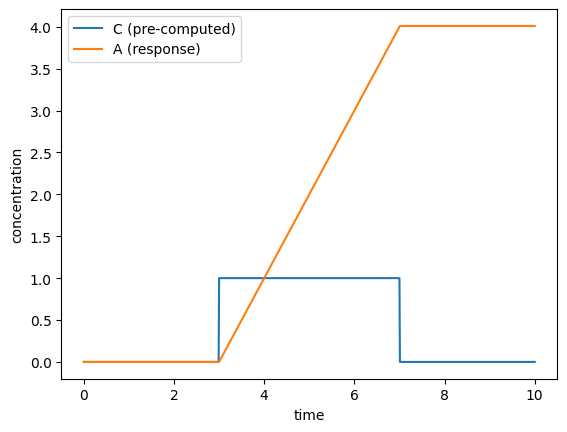

In [4]:
import matplotlib.pyplot as plt

plt.plot(times, result[C], label="C (pre-computed)")
plt.plot(times, result[A], label="A (response)")
plt.legend()
plt.xlabel("time")
plt.ylabel("concentration")
plt.show()